## Simulación de un PID de forma iterativa

Librerías necesarias

In [85]:
import matplotlib.pyplot as plt
import numpy as np

El Proceso a controlar viene descrito por el siguiente modelo discreto obtenido a un período de muestreo, T = 0.1 seg.

$$G_p(z)=\frac{0.007(z+0.94)}{(z-0.95)(z-0.86)}$$

Primero simularemos el comportamiento del proceso sin regulador en lazo cerrado

Expresamos dicha función de transferencia en la ecuación en diferencias equivalente:

$$y(k)=1.81y(k-1)-0.817y(k-2)+0.007u(k-1)+0.0066u(k-2)$$

Definimos las variables que van a almacenar los datos de la simulación así como otros parámetros:

In [86]:
tsim = 15                  # Tiempo de simulación en segundos
T = 0.1                     # Período de muestreo
numiter = int(tsim/T)-2     # Número de iteraciones para la simulación
u = 1                       # Entrada escalón unitario
entrada = []
error = []
errorc = []
accont = []
salida = []
salcont = []

Función que representa gráficamente las señales que nos interesean:

In [87]:
def dibuja(graf):

    ejex = []
    longitud_datos = len(salida)
    for i in range(0, longitud_datos):
        ejex.append(i)

    if graf == 1:
        longitud_datos = len(salida)
        eti_sal = 'Salida'
        eti_ref = 'Referencia'
        color_sal = 'blue'
        color_ref = 'red'
        style_sal = 'solid'
        style_ref = 'solid'
        title_sal = 'Salida sin PID'
        xlabel_sal = f'Muestras (T = {T} seg.)'
        ylabel_sal = 'y(k)'
        ejey_sal = salida
        ejey = entrada
        plt.figure(figsize=(12, 8))

    if graf == 2:
        longitud_datos = len(salcont)
        eti_sal = 'Salida'
        eti_ref = 'Referencia'
        color_sal = 'blue'
        color_ref = 'red'
        style_sal = 'solid'
        style_ref = 'solid'
        title_sal = 'Salida con PID'
        xlabel_sal = f'Muestras (T = {T} seg.)'
        ylabel_sal = 'y(k)'
        ejey_sal = salcont
        ejey = entrada
        plt.figure(figsize=(12, 8))

    if graf == 3:
        longitud_datos = len(salcont)
        eti_sal = 'Salida sin PID'
        eti_ref = 'Salida con PID'
        color_sal = 'blue'
        color_ref = 'red'
        style_sal = 'solid'
        style_ref = 'solid'
        title_sal = 'Comparacón con/sin PID'
        xlabel_sal = f'Muestras (T = {T} seg.)'
        ylabel_sal = 'y(k)'
        ejey = salcont
        ejey_sal = salida
        plt.figure(figsize=(12, 8))
        plt.plot(ejex, entrada, label='Referencia', color='green', linestyle='solid')

    if graf == 4:
        longitud_datos = len(salcont)
        eti_sal = 'Error'
        eti_ref = 'Acc. control.'
        color_sal = 'blue'
        color_ref = 'red'
        style_sal = 'solid'
        style_ref = 'solid'
        title_sal = 'Señal de error/Acción de control'
        xlabel_sal = f'Muestras (T = {T} seg.)'
        ylabel_sal = 'e(k)/u(k)'
        ejey = error
        ejey_sal = accont
        plt.figure(figsize=(12, 8))
        #plt.plot(ejex, entrada, label='Referencia', color='green', linestyle='solid')




     # Opcional: Define el tamaño de la figura
    plt.plot(ejex, ejey_sal, label=eti_sal, color=color_sal, linestyle=style_sal)
    plt.plot(ejex, ejey, label=eti_ref, color=color_ref, linestyle=style_ref)
    plt.title(title_sal)
    plt.xlabel(xlabel_sal)
    plt.ylabel(ylabel_sal)
    plt.legend() # Muestra la leyenda
    plt.grid(True) # Añade una cuadrícula

    # 4. Mostrar la gráfica
    plt.show()

La función 'simula()' obtiene los valores de la simulación sin regulador para instantes de tiempo posteriores al retardo (evitamos índices negativos en el bucle principal).

In [88]:
def simula():
    global ym1, ym2, em1, em2
    for i in range(numiter):
        y = (1.81*ym1)-(0.817*ym2)+(0.007*em1)+(0.0066*em2)
        e = u - ym1
        entrada.append(u)
        error.append(e)
        salida.append(y)

        # Reasignamos las variables
        em2 = em1
        em1 = e
        ym2 = ym1
        ym1 = y

    # print (error)
    # print (salida)

Calculamos previamente los dos primeros valores ya que provocarían índices negativos en el bucle al calcular y(k):

In [89]:
# Iteración k = 0
ek = 0
yk = 0
entrada.append(u)
error.append(ek)
salida.append(yk)

# Iteración k = 1
ek1 = u - yk
yk1 = (1.81*yk)+(0.007*ek1)
entrada.append(u)
error.append(ek1)
salida.append(yk1)

# Iteración k = 2
ek2 = u - yk1
yk2 = (1.81*yk1)-(0.817*yk)+(0.007*ek2)+(0.0066*ek1)
entrada.append(u)
error.append(ek2)
salida.append(yk2)

# Resto de iteraciones
ym1 = yk2
ym2 = yk1
em1 = ek2
em2 = ek1

simula()


Realizamos la obtención del resto de valores mediante un bucle:

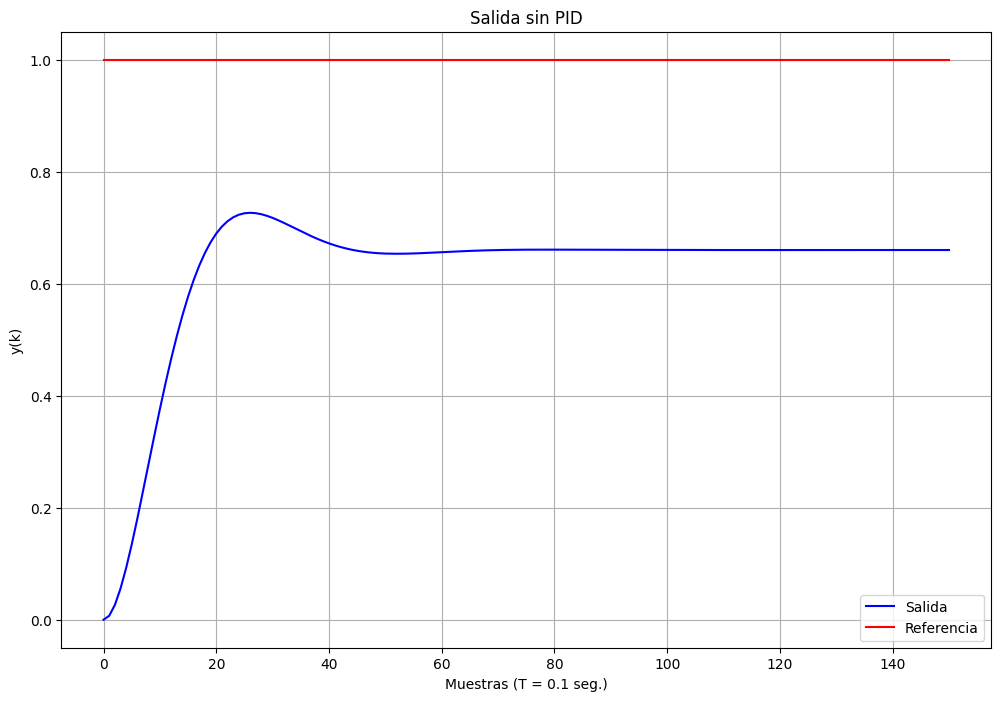

In [90]:
dibuja(1)


Procedemos ahora a simular el sistema controlado con el regulador PID calculado:

$$G_R(z)=18.86\frac{(z-0.967)(z-0.7)}{z(z-1)}

Expresamos la salida del regulador (acción de control) mediante su correspondiente ecuación en diferencias:

$$u(k)=u(k-1)+18.86e(k)-31.4396e(k-1)+12.7663e(k-2)$$

La siuiente función, 'sim_control', obtiene los valores de la salida del sistema en bucle cerrado controlado mediante un regulador PID.

In [91]:
def sim_control():
    global ym1, ym2, em1, em2, acm1, acm2, e, u
    for i in range(numiter):
        ec = u - ym1
        c = acm1+(18.86*ec)-(31.4396*em1)+(12.7663*em2)
        y = (1.81*ym1)-(0.817*ym2)+(0.007*acm1)+(0.0066*acm2)
        #entrada.append(u)
        errorc.append(ec)
        accont.append(c)
        salcont.append(y)

        # Reasignamos las variables
        em2 = em1
        em1 = ec
        acm2 = acm1
        acm1 = c
        ym2 = ym1
        ym1 = y

    # print (error)
    # print (salida)


Calculamos de nuevo los dos primeros valores de la simulación para evitar índices negativos en el bucle principal de cálculo de la salida:

In [92]:
# Iteración k = 0
u = 1       # Entrada escalón unitario
ek = 0
ac = 0
yk = 0
#entrada.append(u)
errorc.append(ek)
accont.append(ac)
salcont.append(yk)

# Iteración k = 1
ek1 = u - yk
ac1 = 18.86*ek1
yk1 = (1.81*yk)+(0.007*ac1)
#entrada.append(u)
errorc.append(ek1)
accont.append(ac1)
salcont.append(yk1)

# Iteración k = 2
ek2 = u - yk1
ac2 = ac1+(18.86*ek2)-(31.4396*ek1)+(12.7663*ek)
yk2 = (1.81*yk1)-(0.817*yk)+(0.007*ac2)+(0.0066*ac1)
#entrada.append(u)
errorc.append(ek2)
accont.append(ac2)
salcont.append(yk2)

ym1 = yk2
ym2 = yk1
em1 = ek2
em2 = ek1
acm1 = ac2
acm2 = ac1
ec = ek2

sim_control()

print(f'Sobreoscilación máxima: ', max(salcont)-u)


Sobreoscilación máxima:  0.49750894351153785


Representamos gráficamente la salida del sistema controlada mediente el regulador PID obtenido mediante las especificaciones junto con la señal de referencia (escalón unitario):

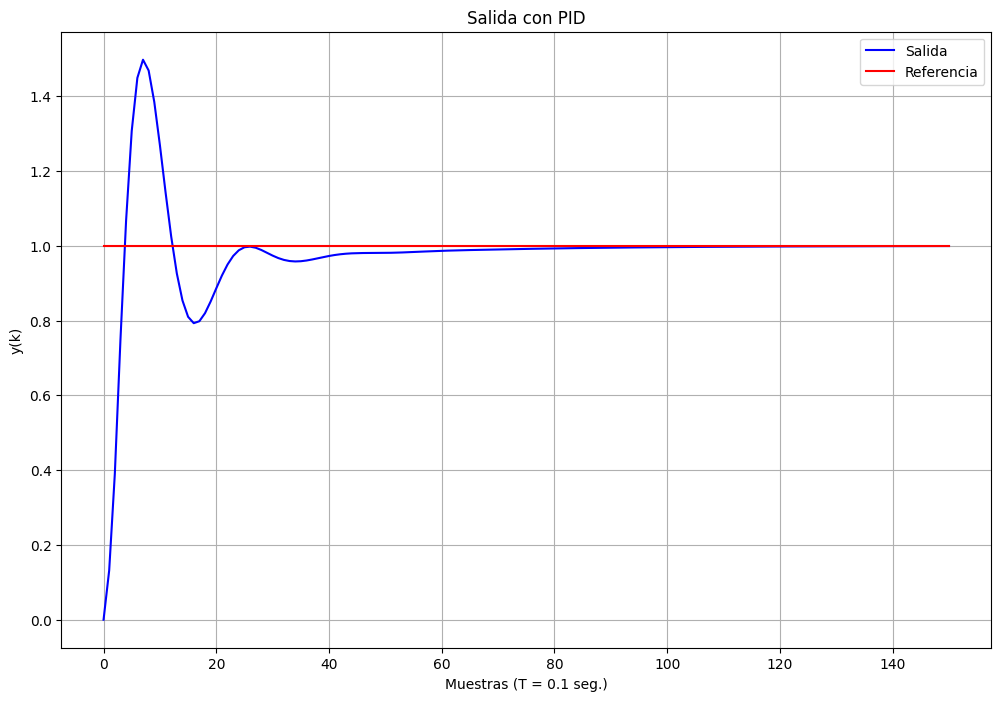

In [93]:
dibuja(2)

Representación gráfica de ambas salidas (controlada/no controlada) y referencia:

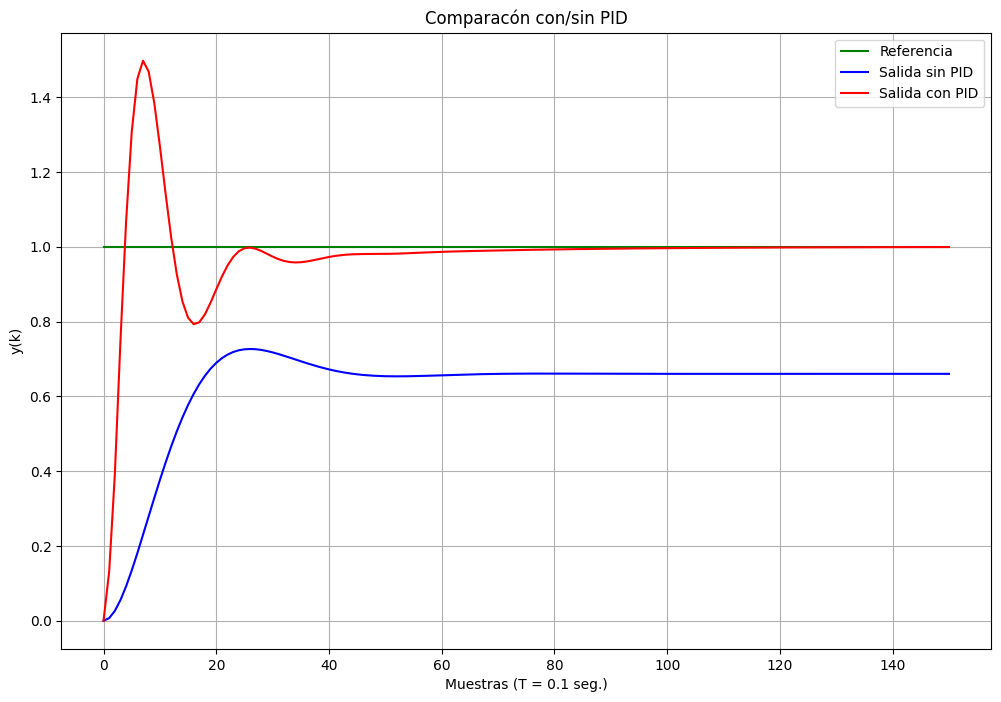

In [94]:
dibuja(3)

Representación de las señales de error y de la acción de control:

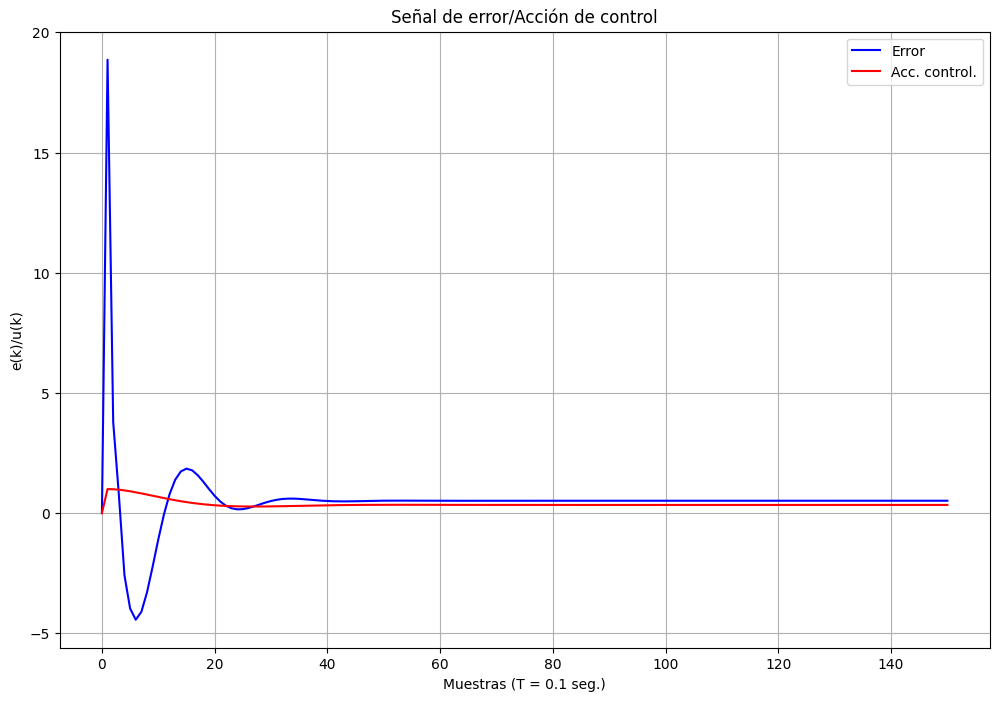

In [95]:
dibuja(4)

In [96]:
print(f"Acción de control:", np.mean(accont[50:100]))
print(f"Error en RP:", np.mean(errorc[50:100]))

Acción de control: 0.5138893310246828
Error en RP: 0.00985047799700723
